# Final NeurIPS submission figures

This notebook produces the paper plots for the two-layer compression story: an LLM token table first maps source bytes to token IDs, and a predictive arithmetic coder then maps those IDs to bits. It reads saved experiment artifacts without rerunning model inference.

Outputs are written to `artifacts/figures/neurips/final/` as vector PDF and 300-DPI PNG files. Assertions make every plotted comparison auditable.

In [1]:
from pathlib import Path
import json, math
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate/'pyproject.toml').exists(): return candidate
    raise FileNotFoundError('Could not locate repository root')
ROOT=find_repo_root(); FIGURE_DIR=ROOT/'artifacts/figures/neurips/final'; FIGURE_DIR.mkdir(parents=True,exist_ok=True)
COLORS={'blue':'#0072B2','orange':'#D55E00','green':'#009E73','purple':'#CC79A7','ink':'#202124','muted':'#6B7280','light':'#D1D5DB','paper':'#FFFFFF'}
mpl.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','font.family':'DejaVu Sans','font.size':8.5,'axes.titlesize':9.5,'axes.titleweight':'bold','axes.labelsize':8.5,'xtick.labelsize':7.5,'ytick.labelsize':7.5,'legend.fontsize':7.4,'axes.spines.top':False,'axes.spines.right':False,'axes.edgecolor':COLORS['ink'],'axes.linewidth':0.7,'pdf.fonttype':42,'ps.fonttype':42,'savefig.bbox':'tight','savefig.pad_inches':0.03})
def save_figure(fig,stem):
    pdf=FIGURE_DIR/f'{stem}.pdf'; png=FIGURE_DIR/f'{stem}.png'; fig.savefig(pdf); fig.savefig(png,dpi=300); print('Saved',pdf.relative_to(ROOT)); print('Saved',png.relative_to(ROOT))

## Load and validate the matched experiments

The full-vocabulary adversarial sequences comprise three completed 10,000-token runs. They were generated once and replayed under an occurring-token mask, then scored with the actual arithmetic coder. The text8 controls match model, context, retained context, KV-cache policy, and arithmetic coding. The one-byte stress test is the earlier verified 1,000-token run; the beam panel remains a clearly labeled 32-token diagnostic.

In [2]:
ADV_DIR=ROOT/'artifacts/runs/paper-evaluation/full_vocab_n10000'
ASCII_DIR=ROOT/'artifacts/runs/adversarial/qwen_05b_ascii_bytes_n1000/full'
PIPELINE_RESULTS=ROOT/'artifacts/runs/current/compression_results.json'
adv={v:json.loads((ADV_DIR/v/'results.json').read_text()) for v in ('full','occurring')}
ascii_results=json.loads((ASCII_DIR/'results.json').read_text()); ascii_check=json.loads((ASCII_DIR/'compression_verification.json').read_text()); coding=json.loads((ADV_DIR/'arithmetic_payloads.json').read_text()); pipeline=json.loads(PIPELINE_RESULTS.read_text())
for f,m in zip(adv['full']['runs'],adv['occurring']['runs']):
    assert f['token_ids']==m['token_ids'] and f['decoded_text_round_trips'] and m['decoded_text_round_trips']
    # The replay is authoritative for scores: generation checkpoints in this preliminary artifact reset the retained context too aggressively.
assert adv['occurring']['metadata']['mask_application']=='post-hoc rescoring' and adv['occurring']['metadata']['same_token_ids_as_full'] is True
assert len(adv['full']['runs'])==len(adv['occurring']['runs'])==3 and all(len(r['token_ids'])==10000 for r in adv['full']['runs'])
assert len(coding['runs'])==6 and {r['policy'] for r in coding['runs']}=={'full','occurring'}
assert ascii_check['token_round_trip'] and ascii_check['byte_round_trip'] and ascii_check['serialized_artifact_token_round_trip'] and ascii_check['serialized_artifact_byte_round_trip']
model_name=adv['full']['metadata']['model_name']; vocab_size=adv['full']['runs'][0]['summary']['candidate_size']; fixed_id_bits=math.ceil(math.log2(vocab_size))
assert model_name=='Qwen/Qwen2.5-0.5B' and vocab_size==151643 and fixed_id_bits==18

def find_text8(reduce):
    hits=[]
    for entry in pipeline.values():
        c=entry.get('compression',{}); a=c.get('args',{})
        if (Path(str(a.get('input_path',''))).name=='text8' and a.get('model_name')==model_name and a.get('first_n_tokens')==100000 and a.get('context_length')==1000 and a.get('retain_tokens')==100 and a.get('use_kv_cache') is True and a.get('batch_size')==16 and a.get('encoding')=='AC' and a.get('reduce_tokens') is reduce and a.get('lora_path') is None): hits.append(c)
    assert len(hits)==1; return hits[0]
text8={'full':find_text8(False),'occurring':find_text8(True)}
assert text8['full']['original_size_bytes']==text8['occurring']['original_size_bytes']

In [3]:
def adv_rate(field):
    return np.array([100*(fixed_id_bits-sum(x/math.log(2) for x in r[field]))/(8*r['decoded_utf8_size_bytes']) for r in adv['occurring']['runs']])
def adv_fixed():
    return np.array([100*fixed_id_bits*r['summary']['total_tokens']/(8*r['decoded_utf8_size_bytes']) for r in adv['full']['runs']])
def text8_metrics(v):
    r=text8[v]; n=r['args']['first_n_tokens']; b=r['args']['batch_size']; raw=8*r['original_size_bytes']
    return {'fixed':100*n*fixed_id_bits/raw,'floor':100*(b*fixed_id_bits+r['entropy'])/raw,'payload':100*r['arithmetic_code_size_bytes']/r['original_size_bytes'],'total':100*r['final_size_bytes']/r['original_size_bytes'],'bitmap':100*r['bitmap_size_bytes']/r['original_size_bytes']}
tm={v:text8_metrics(v) for v in ('full','occurring')}
coding_total={v:np.array([100*r['payload_plus_seed_and_dictionary_ratio'] for r in coding['runs'] if r['policy']==v]) for v in ('full','occurring')}
ac=ascii_check['compression']; raw=ac['original_size_bytes']; n=ascii_results['runs'][0]['summary']['total_tokens']
ascii_floor=100*(fixed_id_bits+ac['entropy'])/(8*raw); ascii_fixed=100*n*fixed_id_bits/(8*raw); ascii_payload=100*ac['arithmetic_code_size_bytes']/raw; ascii_total=100*ac['final_size_bytes']/raw; ascii_serial=ascii_check['serialized_file_ratio_percent']
summary=pd.DataFrame([{'condition':'Typical text8','fixed':tm['full']['fixed'],'surprisal':tm['full']['floor'],'total':tm['full']['total'],'serialized':np.nan},{'condition':'Full-vocabulary adversary','fixed':adv_fixed().mean(),'surprisal':adv_rate('model_log_probabilities').mean(),'total':coding_total['full'].mean(),'serialized':np.nan},{'condition':'One-byte adversary','fixed':ascii_fixed,'surprisal':ascii_floor,'total':ascii_total,'serialized':ascii_serial}])
masking=pd.DataFrame([{'dataset':'Typical text8','full':tm['full']['floor'],'occurring':tm['occurring']['floor']},{'dataset':'Adversarial worst case','full':adv_rate('model_log_probabilities').mean(),'occurring':adv_rate('masked_log_probabilities').mean()}])
display(summary.round(3)); display(masking.round(3)); print('Full-vocabulary AC total:',round(coding_total['full'].mean(),3),'%'); print('One-byte AC payload:',round(ascii_payload,3),'%')

,condition,fixed,surprisal,total,serialized
0,Typical text8,42.241,11.631,14.405,NaN
1,Full-vocabulary adversary,31.754,47.374,31.677,NaN
2,One-byte adversary,225.000,105.337,123.912,155.2


,dataset,full,occurring
0,Typical text8,11.631,11.352
1,Adversarial worst case,47.374,33.946


Full-vocabulary AC total: 31.677 %
One-byte AC payload: 120.412 %


## Main figure: tokenization can buffer or expose predictive failure

Panel **a** separates model surprisal from the realized arithmetic total. For the 10,000-token full-vocabulary runs, finite-frequency quantization clips rare-symbol code lengths near 18 bits, so realized arithmetic size is below the unquantized model surprisal estimate. The one-byte adversary removes tokenizer fertility as a buffer and expands. Panel **b** holds token IDs fixed and changes only mask normalization.

Saved artifacts/figures/neurips/final/layered_compression_robustness.pdf
Saved artifacts/figures/neurips/final/layered_compression_robustness.png


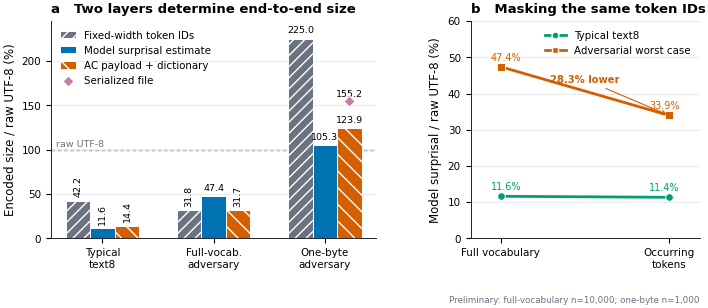

In [4]:
fig,(left,right)=plt.subplots(1,2,figsize=(7.05,3.15),gridspec_kw={'width_ratios':[1.42,1.0]})
conditions=['Typical\ntext8','Full-vocab.\nadversary','One-byte\nadversary']; x=np.arange(3); width=.22
metrics=[('fixed','Fixed-width token IDs',COLORS['muted'],'///'),('surprisal','Model surprisal estimate',COLORS['blue'],''),('total','AC payload + dictionary',COLORS['orange'],'\\\\')]
for off,(col,label,color,hatch) in zip((-1,0,1),metrics):
    vals=summary[col].to_numpy(float); bars=left.bar(x+off*width,vals,width,color=color,edgecolor='white',linewidth=.7,hatch=hatch,label=label,zorder=3)
    for bar,val in zip(bars,vals):
        if np.isfinite(val): left.text(bar.get_x()+bar.get_width()/2,val+4.2,f'{val:.1f}',ha='center',va='bottom',fontsize=6.8,rotation=90 if val<45 else 0)
left.scatter(x[2]+width,summary.loc[2,'serialized'],marker='D',s=31,color=COLORS['purple'],edgecolor='white',linewidth=.7,zorder=5,label='Serialized file'); left.text(x[2]+width,summary.loc[2,'serialized']+5,f"{summary.loc[2,'serialized']:.1f}",ha='center',fontsize=6.8)
left.axhline(100,color=COLORS['ink'],linestyle=(0,(3,2)),linewidth=.9,zorder=1); left.text(-.42,103,'raw UTF-8',fontsize=6.8,color=COLORS['muted'])
left.set(ylim=(0,245),ylabel='Encoded size / raw UTF-8 (%)'); left.set_xticks(x,conditions); left.set_title('a   Two layers determine end-to-end size',loc='left'); left.grid(axis='y',color='#E5E7EB',linewidth=.6,zorder=0); handles, legend_labels = left.get_legend_handles_labels()
legend_map = dict(zip(legend_labels, handles))
legend_order = ['Fixed-width token IDs', 'Model surprisal estimate', 'AC payload + dictionary', 'Serialized file']
left.legend([legend_map[label] for label in legend_order], legend_order, loc='upper left', frameon=False, handlelength=1.5)
styles={'Typical text8':(COLORS['green'],'o'),'Adversarial worst case':(COLORS['orange'],'s')}
for _,row in masking.iterrows():
    color,marker=styles[row['dataset']]; vals=np.array([row['full'],row['occurring']]); right.plot([0,1],vals,color=color,lw=2,marker=marker,markersize=5.5,markeredgecolor='white',markeredgewidth=.7,zorder=3); right.text(.03,vals[0]+1.8,f'{vals[0]:.1f}%',color=color,fontsize=7,ha='center'); right.text(.97,vals[1]+1.8,f'{vals[1]:.1f}%',color=color,fontsize=7,ha='center')
reduction=100*(1-masking.loc[1,'occurring']/masking.loc[1,'full']); right.annotate(f'{reduction:.1f}% lower',xy=(1,masking.loc[1,'occurring']),xytext=(.5,43),ha='center',fontsize=7.2,color=COLORS['orange'],fontweight='bold',arrowprops={'arrowstyle':'->','color':COLORS['orange'],'lw':.8})
right.set(xlim=(-.18,1.18),ylim=(0,60),ylabel='Model surprisal / raw UTF-8 (%)'); right.set_xticks([0,1],['Full vocabulary','Occurring\ntokens']); right.set_title('b   Masking the same token IDs',loc='left'); right.grid(axis='y',color='#E5E7EB',linewidth=.6,zorder=0)
right.legend(handles=[Line2D([0],[0],color=c,marker=m,lw=2,markersize=5,markeredgecolor='white',label=l) for l,(c,m) in styles.items()],loc='upper right',frameon=False)
fig.text(.995,.015,'Preliminary: full-vocabulary n=10,000; one-byte n=1,000',ha='right',fontsize=6.3,color=COLORS['muted']); fig.subplots_adjust(left=.075,right=.995,top=.91,bottom=.22,wspace=.34); save_figure(fig,'layered_compression_robustness'); plt.show()

## Coder-aware attack validation

This compact diagnostic excludes serialized totals because 2,783 fixed bits dominate at only 32 tokens. It compares the model floor with the realized arithmetic payload. This belongs in supplementary material or a short method-validation panel.

Saved artifacts/figures/neurips/final/coder_aware_attack_validation.pdf
Saved artifacts/figures/neurips/final/coder_aware_attack_validation.png


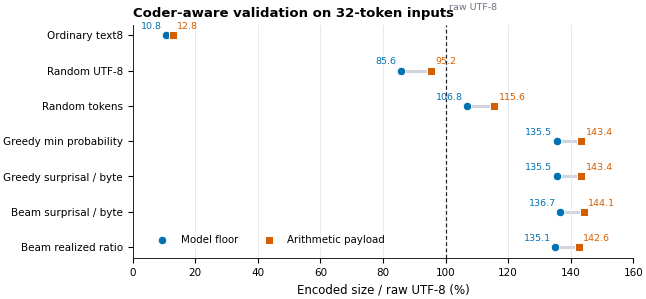

In [5]:
p=json.loads((ROOT/'artifacts/runs/compression-attacks/qwen_05b_ascii_n32_smoke/results.json').read_text()); assert p['metadata']['total_length']==32 and p['metadata']['generation_alphabet']=='ascii-bytes' and p['metadata']['beam_width']==2 and p['metadata']['branch_factor']==4
labels={'ordinary-text8':'Ordinary text8','random-printable-utf8':'Random UTF-8','random-token':'Random tokens','min-probability':'Greedy min probability','surprisal-per-byte':'Greedy surprisal / byte','beam-surprisal-per-byte':'Beam surprisal / byte','beam-actual-ratio':'Beam realized ratio'}
rows=[{'condition':r['condition'],'label':labels[r['condition']],'floor':100*r['model_entropy_ratio'],'payload':100*r['arithmetic_payload_ratio']} for r in p['runs']]; attacks=pd.DataFrame(rows).set_index('condition').loc[list(labels)].reset_index()
fig,ax=plt.subplots(figsize=(7.05,3.15)); y=np.arange(len(attacks))
for yi,row in attacks.iterrows(): ax.plot([row['floor'],row['payload']],[yi,yi],color=COLORS['light'],lw=2.2,zorder=1)
ax.scatter(attacks['floor'],y,s=38,color=COLORS['blue'],edgecolor='white',linewidth=.7,label='Model floor',zorder=3); ax.scatter(attacks['payload'],y,s=40,marker='s',color=COLORS['orange'],edgecolor='white',linewidth=.7,label='Arithmetic payload',zorder=3)
for yi,row in attacks.iterrows(): ax.text(row['floor']-1.4,yi-.18,f"{row['floor']:.1f}",ha='right',fontsize=6.8,color=COLORS['blue']); ax.text(row['payload']+1.4,yi-.18,f"{row['payload']:.1f}",ha='left',fontsize=6.8,color=COLORS['orange'])
ax.axvline(100,color=COLORS['ink'],linestyle=(0,(3,2)),lw=.9); ax.text(101,-.72,'raw UTF-8',fontsize=6.8,color=COLORS['muted']); ax.set_yticks(y,attacks['label']); ax.invert_yaxis(); ax.set(xlim=(0,160),xlabel='Encoded size / raw UTF-8 (%)'); ax.set_title('Coder-aware validation on 32-token inputs',loc='left'); ax.grid(axis='x',color='#E5E7EB',linewidth=.6,zorder=0); ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0.02, 0.015), ncol=2); fig.subplots_adjust(left=.27,right=.98,top=.90,bottom=.16); save_figure(fig,'coder_aware_attack_validation'); plt.show()

## Submission guidance

- Use `layered_compression_robustness.pdf` as the main four-page figure.
- Use `coder_aware_attack_validation.pdf` only in supplementary material unless space permits; its 32-token search is preliminary.
- The full-vocabulary panel now includes three realized 10,000-token arithmetic totals; model surprisal is shown separately because finite-frequency quantization clips rare-symbol code lengths.
- A replacement full-vocabulary generation is needed after the checkpoint-context fix. The current figure uses continuous replay scores for its fixed IDs, so it is useful as a preliminary result but not the final attack sweep.
- The printable-ASCII and 10,000-token one-byte matrices and the planned 512-token beam search are also missing. Current one-byte and beam values are explicitly preliminary fallbacks.
- Include PDFs in LaTeX to preserve vector text and lines.